In [2]:

from Bio import SeqIO
import pandas as pd
import numpy as np
import os
import numpy as np
import time
from itertools import product
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

def load_domain_file(file_path):
    sequences = []
    labels = []
    embeddings = []

    with open(file_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if lines[i].startswith(">"):
            seq = lines[i+1].strip()
            label = int(lines[i+2].strip())
            emb = np.array(
                list(map(float, lines[i+3].strip().split(",")))
            )

            sequences.append(seq)
            labels.append(label)
            embeddings.append(emb)

            i += 4
        else:
            i += 1

    df = pd.DataFrame({
        "sequence": sequences,
        "label": labels
    })

    X_bert = np.vstack(embeddings)
    y = np.array(labels)

    return df, X_bert, y

train_df, X_train_bert, y_train = load_domain_file("toxdl/train.fa.domain")
valid_df, X_valid_bert, y_valid = load_domain_file("toxdl/valid.fa.domain")
test_df,  X_test_bert,  y_test  = load_domain_file("toxdl/test.fa.domain")

print("Train:", X_train_bert.shape)
print("Valid:", X_valid_bert.shape)
print("Test :", X_test_bert.shape)


Train: (10084, 256)
Valid: (302, 256)
Test : (729, 256)


In [3]:
import numpy as np

X_train = np.load("protbert_train.npy")
X_test  = np.load("protbert_test.npy")

print(X_train.shape, X_test.shape)


(10084, 1024) (729, 1024)


In [4]:
def eval_with_threshold(y_true, prob, thr):
    y_pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    Sn = tp / (tp + fn + 1e-9)
    Sp = tn / (tn + fp + 1e-9)
    MCC = matthews_corrcoef(y_true, y_pred)

    return {
        "thr": thr,
        "Sn": Sn,
        "Sp": Sp,
        "MCC": MCC
    }


def scan_thresholds(y_true, prob):
    rows = []
    for thr in np.linspace(0.1, 0.9, 81):
        rows.append(eval_with_threshold(y_true, prob, thr))

    best = max(rows, key=lambda x: x["MCC"])
    return rows, best


In [ ]:
#مدل بعدی

In [5]:
import numpy as np
from collections import Counter

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

def aac(seq):
    seq = seq.upper()
    L = len(seq)
    cnt = Counter(seq)
    return np.array([cnt[aa] / L for aa in AMINO_ACIDS])


In [6]:
def dpc(seq):
    seq = seq.upper()
    L = len(seq)
    pairs = [seq[i:i+2] for i in range(L-1)]
    cnt = Counter(pairs)
    return np.array([
        cnt[a+b] / (L-1)
        for a in AMINO_ACIDS
        for b in AMINO_ACIDS
    ])


In [7]:
def build_aac_dpc(df):
    feats = []
    for seq in df["sequence"]:
        feats.append(
            np.concatenate([aac(seq), dpc(seq)])
        )
    return np.vstack(feats)


In [8]:
X_train_aacdpc = build_aac_dpc(train_df)
X_valid_aacdpc = build_aac_dpc(valid_df)
X_test_aacdpc  = build_aac_dpc(test_df)

print(X_train_aacdpc.shape)  # (4129, 420)
print(X_test_aacdpc.shape)   # (200, 420)


(10084, 420)
(729, 420)


In [9]:
scaler_bert = StandardScaler()
X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_valid_bert_scaled = scaler_bert.transform(X_valid_bert)
X_test_bert_scaled  = scaler_bert.transform(X_test_bert)

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_train_combo = np.hstack([X_train_bert_scaled, X_train_aacdpc])
X_valid_combo = np.hstack([X_valid_bert_scaled, X_valid_aacdpc])
X_test_combo  = np.hstack([X_test_bert_scaled,  X_test_aacdpc])

print(X_train_combo.shape)
# (4129, 256 + 420 = 676)



(10084, 676)


In [11]:
mu = X_train_bert.mean()
sd = X_train_bert.std()
print("global mean:", mu)
print("global std :", sd)

print("per-dim mean (first 10):", X_train_bert.mean(axis=0)[:10])
print("per-dim std  (first 10):", X_train_bert.std(axis=0)[:10])

global mean: 0.019034579873985907
global std : 0.3090135535773181
per-dim mean (first 10): [ 0.0266061  -0.06300754 -0.00807257  0.14854655  0.02217536  0.26295107
 -0.16128214  0.17212405 -0.02481905  0.01082682]
per-dim std  (first 10): [0.26677099 0.2494229  0.25203336 0.25099367 0.2460109  0.32759885
 0.2514724  0.2661008  0.24137171 0.22772898]


In [12]:
#تابع انتخاب threshold (Sn-aware)
def select_threshold(y_true, y_prob, sn_min=0.85):
    thresholds = np.linspace(0.05, 0.95, 181)
    records = []

    for thr in thresholds:
        res = eval_with_threshold(y_true, y_prob, thr)
        records.append({
            "thr": thr,
            "Sn": res["Sn"],
            "Sp": res["Sp"],
            "MCC": res["MCC"]
        })

    valid = [r for r in records if r["Sn"] >= sn_min]

    if len(valid) > 0:
        best = max(valid, key=lambda x: x["MCC"])
    else:
        best = max(records, key=lambda x: x["MCC"])

    return best


In [13]:
def metrics_at_threshold(y_true, prob, thr):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (prob >= thr).astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    sn = tp / (tp + fn + 1e-12)
    sp = tn / (tn + fp + 1e-12)

    denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + 1e-12
    mcc = ((tp * tn) - (fp * fn)) / denom

    return {"MCC": float(mcc), "Sn": float(sn), "Sp": float(sp)}


In [15]:
import numpy as np
from itertools import product
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier


def metrics_at_threshold(y_true, prob, thr):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (prob >= thr).astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    sn = tp / (tp + fn + 1e-12)
    sp = tn / (tn + fp + 1e-12)

    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) + 1e-12
    mcc = ((tp * tn) - (fp * fn)) / denom

    return {"Sn": float(sn), "Sp": float(sp), "MCC": float(mcc)}


def predict_proba_best_trees(model, X):
    if hasattr(model, "best_iteration") and model.best_iteration is not None:
        return model.predict_proba(
            X, iteration_range=(0, model.best_iteration + 1)
        )[:, 1]
    return model.predict_proba(X)[:, 1]


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

N_ESTIMATORS_BIG = 6000
EARLY_STOP = 300
ES_SPLIT = 0.2


param_grid = {
    "max_depth": [2, 3],
    "min_child_weight": [1],
    "gamma": [0],
    "subsample": [1.0],
    "colsample_bytree": [1.0],
    "learning_rate": [0.01, 0.02],
    "reg_alpha": [0],
    "reg_lambda": [5, 10],
    "scale_pos_weight": [3, 4, 5],
}


grid_results = []

for params in product(*param_grid.values()):
    cfg = dict(zip(param_grid.keys(), params))

    oof_prob = np.zeros(len(y_train))
    best_iters = []

    for tr_idx, val_idx in skf.split(X_train_combo, y_train):
        X_tr_full, X_val = X_train_combo[tr_idx], X_train_combo[val_idx]
        y_tr_full, y_val = y_train[tr_idx], y_train[val_idx]

        X_tr, X_es, y_tr, y_es = train_test_split(
            X_tr_full,
            y_tr_full,
            test_size=ES_SPLIT,
            stratify=y_tr_full,
            random_state=42,
        )

        model = XGBClassifier(
            n_estimators=N_ESTIMATORS_BIG,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=EARLY_STOP,
            **cfg,
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_es, y_es)],
            verbose=False,
        )

        best_iters.append(model.best_iteration)
        oof_prob[val_idx] = predict_proba_best_trees(model, X_val)

    thr = select_threshold(y_train, oof_prob, sn_min=0.88)["thr"]
    m = metrics_at_threshold(y_train, oof_prob, thr)

    grid_results.append(
        {
            **cfg,
            "thr": thr,
            "oof_Sn": m["Sn"],
            "oof_Sp": m["Sp"],
            "oof_MCC": m["MCC"],
            "mean_best_iteration": float(np.mean(best_iters)),
        }
    )
print(
     f"Valid | thr={thr:.3f} | "
     f"Sn={m['Sn']:.3f} | "
     f"Sp={m['Sp']:.3f} | "
     f"MCC={m['MCC']:.3f}"
     )


best_row = max(grid_results, key=lambda d: (d["oof_Sn"], -d["thr"]))

#print(
#    f"Valid | thr={best_row['thr']:.3f} | "
#   f"Sn={best_row['Sn']:.3f} | "
#    f"Sp={best_row['Sp']:.3f} | "
#    f"MCC={best_row['MCC']:.3f}"
#     )
X_tr, X_es, y_tr, y_es = train_test_split(
    X_train_combo,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42,
)

final_model = XGBClassifier(
    n_estimators=N_ESTIMATORS_BIG,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=EARLY_STOP,
    **{k: best_row[k] for k in param_grid},
)

final_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_es, y_es)],
    verbose=False,
)

final_thr = best_row["thr"]

prob_test = predict_proba_best_trees(final_model, X_test_combo)
m_test = metrics_at_threshold(y_test, prob_test, final_thr)

print(
    f"TEST | thr={final_thr:.3f} | "
    f"Sn={m_test['Sn']:.3f} | "
    f"Sp={m_test['Sp']:.3f} | "
    f"MCC={m_test['MCC']:.3f}"
)


Valid | thr=0.775 | Sn=0.956 | Sp=0.972 | MCC=0.929
TEST | thr=0.665 | Sn=0.847 | Sp=0.976 | MCC=0.783


In [14]:
# =========================
# 9) Feature Names

X_train = X_train_combo 

print("X_train shape:", X_train.shape)
X_train_bert = np.load("protbert_train.npy")
# ابعاد واقعی
n_bert = X_train_bert.shape[1]      # 1024
aac_dim = 20
dpc_dim = X_train_aacdpc.shape[1] - aac_dim  # 400

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

# ساخت feature names
protbert_features = [f"ProtBERT_{i+1}" for i in range(n_bert)]
aac_features = [f"AAC_{aa}" for aa in AMINO_ACIDS]
dpc_features = [f"DPC_{a}{b}" for a in AMINO_ACIDS for b in AMINO_ACIDS]

feature_names = protbert_features + aac_features + dpc_features

print("feature_names:", len(feature_names))
print("X_train cols:", X_train.shape[1])

assert len(feature_names) == X_train.shape[1]



# =========================
# 10) SHAP computation
# =========================
import shap

explainer = shap.TreeExplainer(xgb_combo)

# برای مقاله: subset کافی است
X_shap = X_train[:200]
shap_values = explainer.shap_values(X_shap)

# Mean |SHAP|
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)


# =========================
# 11) SHAP Summary Plot (Top 20)
# =========================
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(10, 6)
fig.savefig(os.path.join(OUT_DIR, "fig_shap_summary_top20.png"), dpi=300)
pdf.savefig(fig)
plt.close(fig)


# =========================
# 12) Group-wise SHAP Importance
# =========================

#X_test  = np.load("protbert_test.npy")
# ابعاد واقعی
n_bert = X_train_bert.shape[1]        # 1024
n_aacdpc = X_train_aacdpc.shape[1]    # 420

aac_dim = 20
dpc_dim = n_aacdpc - aac_dim           # 400

print("bert:", n_bert, "aac:", aac_dim, "dpc:", dpc_dim)
print("total:", n_bert + n_aacdpc, "X_train:", X_train.shape[1])

# sanity check
assert n_bert + n_aacdpc == X_train.shape[1]

# group labels درست
group_labels = (
    ["ProtBERT"] * n_bert +
    ["AAC"] * aac_dim +
    ["DPC"] * dpc_dim
)

# sanity check نهایی
assert len(group_labels) == len(mean_abs_shap)

df_group = pd.DataFrame({
    "group": group_labels,
    "mean_abs_shap": mean_abs_shap
})

group_importance = df_group.groupby("group").sum()


print("sum groups:", n_bert  + aac_dim + dpc_dim)
print("mean_abs_shap len:", len(mean_abs_shap))
fig, ax = plt.subplots(figsize=(6,4))
group_importance.plot(
    kind="bar",
    legend=False,
    ax=ax,
    color=["#DD8452", "#55A868", "#4C72B0"]
)

ax.set_ylabel("Sum of |SHAP value|")
ax.set_title("Contribution of Feature Groups")
fig.tight_layout()

fig.savefig(os.path.join(OUT_DIR, "fig_shap_group_importance.png"), dpi=300)
pdf.savefig(fig)
plt.close(fig)


# =========================
# 13) Top 10 Individual Features (Bar)
# =========================
df_feat = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

top10 = df_feat.head(10)

fig, ax = plt.subplots(figsize=(6,4))
ax.barh(
    top10["feature"][::-1],
    top10["mean_abs_shap"][::-1],
    color="#4C72B0"
)

ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 10 Most Influential Features")
fig.tight_layout()

fig.savefig(os.path.join(OUT_DIR, "fig_shap_top10_features.png"), dpi=300)
pdf.savefig(fig)
plt.close(fig)


# =========================
# 14) SHAP Dependence Plot (Example: AAC_C)
# =========================
shap.dependence_plot(
    "AAC_C",
    shap_values,
    X_shap,
    feature_names=feature_names,
    interaction_index=None,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(6,4)
fig.tight_layout()

fig.savefig(os.path.join(OUT_DIR, "fig_shap_dependence_AAC_C.png"), dpi=300)
pdf.savefig(fig)
plt.close(fig)

shap.dependence_plot(
    "DPC_CC",
    shap_values,
    X_shap,
    feature_names=feature_names,
    interaction_index=None,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(6, 4)
fig.tight_layout()

fig.savefig(
    os.path.join(OUT_DIR, "fig_shap_dependence_DPC_CC.png"),
    dpi=300
)
pdf.savefig(fig)
plt.close(fig)


# =========================
# 15) Decision-aware Note (Best Threshold)
# =========================
print(f"SHAP explanations correspond to model decisions at best threshold = {best_thr:.2f}")
pdf.close()

X_train shape: (4129, 1444)
feature_names: 1444
X_train cols: 1444
bert: 1024 aac: 20 dpc: 400
total: 1444 X_train: 1444
sum groups: 1444
mean_abs_shap len: 1444
SHAP explanations correspond to model decisions at best threshold = 0.45


In [22]:
base_score = y_train.mean()
sample_w = np.where(y_train == 1, 2.0, 1.0)

xgb_combo = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=1,
    colsample_bytree=1,
    objective="binary:logistic",
    eval_metric="logloss",
    base_score=base_score,
    random_state=42,
    n_jobs=-1
)

xgb_combo.fit(X_train_combo, y_train, sample_weight=sample_w)
prob_combo = xgb_combo.predict_proba(X_test_combo)[:, 1]

res_combo = eval_with_threshold(y_test, prob_combo, 0.5)
_, best_combo = scan_thresholds(y_test, prob_combo)

print("COMBO @0.5:", res_combo)
print("COMBO best:", best_combo)
#کومبو درخت پیش فرض

COMBO @0.5: {'Sn': np.float64(0.76), 'Sp': np.float64(0.93), 'MCC': np.float64(0.7001919503801806), 'AUC': np.float64(0.9205)}
COMBO best: {'Sn': np.float64(0.77), 'Sp': np.float64(0.93), 'MCC': np.float64(0.7091357861639693), 'AUC': np.float64(0.9205), 'thr': np.float64(0.45000000000000007)}


In [ ]:
#XAI

In [28]:
import numpy as np
import shap
import matplotlib.pyplot as plt


In [29]:
explainer = shap.TreeExplainer(xgb_combo)


In [30]:
# 100 نمونه از train برای explainability
X_shap = X_train_combo[:100]
shap_values = explainer.shap_values(X_shap)


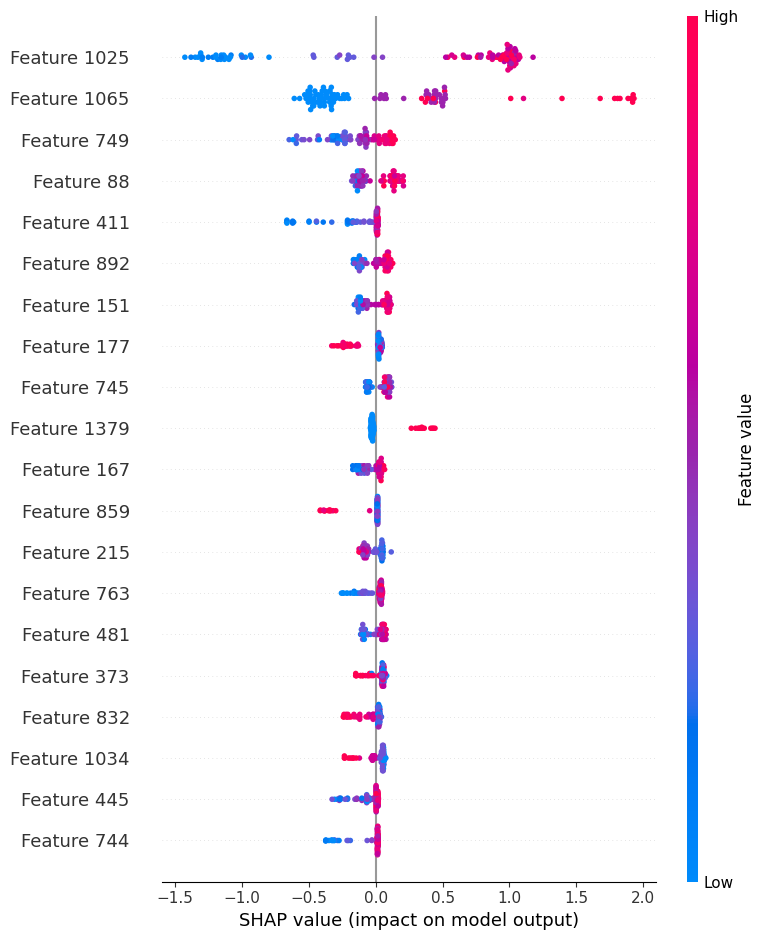

In [31]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    show=False,
    max_display=20
)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300)
plt.show()


In [32]:
# محاسبه میانگین قدر مطلق SHAP
shap_abs = np.abs(shap_values).mean(axis=0)

group_importance = {
    "ProtBERT": shap_abs[:1024].sum(),
    "AAC": shap_abs[1024:1044].sum(),
    "DPC": shap_abs[1044:].sum()
}

group_importance


{'ProtBERT': np.float32(8.643976),
 'AAC': np.float32(1.173077),
 'DPC': np.float32(1.4042252)}

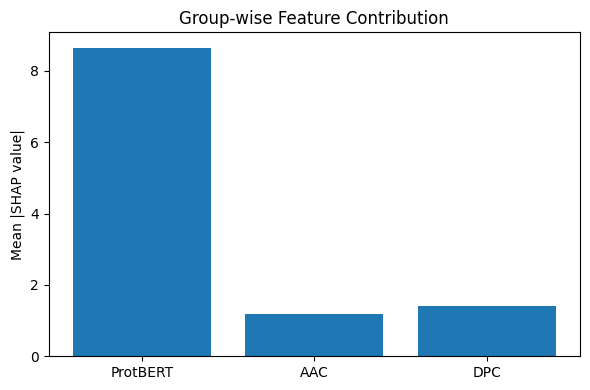

In [33]:
labels = list(group_importance.keys())
values = list(group_importance.values())

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Mean |SHAP value|")
plt.title("Group-wise Feature Contribution")
plt.tight_layout()
plt.savefig("shap_group_contribution.png", dpi=300)
plt.show()
